# TP3 - Template Matching

## Punto 1 - Obtener detección del logo de Coca en las imagenes sin falsos positivos

Se evalúan distintos enfoques provistos por OpenCV para encontrar coincidencias entre una imagen y un template.

In [86]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

TEMPLATE_FILE = "./template/pattern.png"
DATASET_DIR = "./images/"

In [105]:
# Template original
template_rgb = cv2.imread(TEMPLATE_FILE, cv2.IMREAD_COLOR)

if template_rgb is None:
    raise Exception("No se pudo cargar el template")

# Imágenes
dataset = []
names = []

for fname in os.listdir(DATASET_DIR):
    if "multi" in fname:
        continue

    img = cv2.imread(os.path.join(DATASET_DIR, fname))
    if img is not None:
        dataset.append(img)
        names.append(fname)

print(f"Cantidad de imágenes: {len(dataset)}")

Cantidad de imágenes: 6


In [107]:
def preprocess_frame(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # suavizado
    smooth = cv2.GaussianBlur(gray, (7,7), 0)
    
    return smooth

Se hace un preprocesamiento ya que se detecto que al aplicarlo al template original no se obtienen buenos resultados.

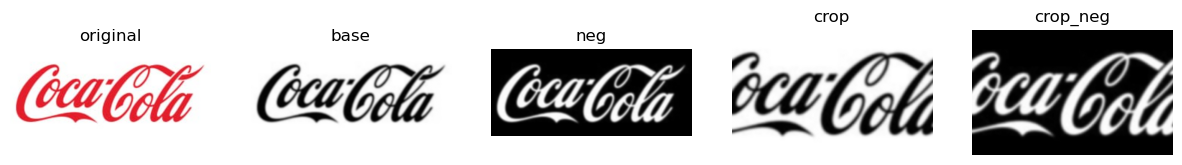

In [108]:
base = preprocess_frame(template_rgb)

# generamos variantes
templates_bank = []

templates_bank.append(("base", base))
templates_bank.append(("neg", 255 - base))

# recorte
crop_l = 60
crop_r = base.shape[1] - 60

templates_bank.append(("crop", base[:, crop_l:crop_r]))
templates_bank.append(("crop_neg", (255 - base)[:, crop_l:crop_r]))

# visualización
fig, axs = plt.subplots(1, len(templates_bank)+1, figsize=(15,5))

axs[0].imshow(cv2.cvtColor(template_rgb, cv2.COLOR_BGR2RGB))
axs[0].set_title("original")

for i, (name, t) in enumerate(templates_bank):
    axs[i+1].imshow(t, cmap="gray")
    axs[i+1].set_title(name)

for ax in axs:
    ax.axis("off")

plt.show()

Genero muchas versiones del mismo template a distintas escalas

In [109]:
def build_scaled_templates(template, min_s=0.3, max_s=3.5, step=0.15):
    scaled = []
    scales = np.arange(min_s, max_s, step)

    for s in scales:
        resized = cv2.resize(template, None, fx=s, fy=s, interpolation=cv2.INTER_LINEAR)
        scaled.append(resized)

    return scaled, scales

In [110]:
scaled_templates = []

for name, t in templates_bank:
    pyr, _ = build_scaled_templates(t)
    for elem in pyr:
        if elem.shape[0] > 10 and elem.shape[1] > 10:
            scaled_templates.append(elem)

print("Templates generados:", len(scaled_templates))

Templates generados: 88


Calculo qué tan parecido es el solapamiento entre dos bounding boxes

In [111]:
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]

    union = areaA + areaB - inter

    return inter/union if union > 0 else 0


def apply_nms(boxes, scores, thr=0.3):
    idxs = np.argsort(scores)[::-1]

    selected_boxes = []
    selected_scores = []

    while len(idxs) > 0:
        i = idxs[0]
        selected_boxes.append(boxes[i])
        selected_scores.append(scores[i])

        keep = []
        for j in idxs[1:]:
            if iou(boxes[i], boxes[j]) < thr:
                keep.append(j)

        idxs = np.array(keep)

    return selected_boxes, selected_scores

In [112]:
def detect_object(img, templates, method, score_thr=0.5):
    proc = preprocess_frame(img)

    boxes = []
    scores = []

    for t in templates:
        th, tw = t.shape

        if th > proc.shape[0] or tw > proc.shape[1]:
            continue

        res = cv2.matchTemplate(proc, t, method)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

        if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
            score = min_val
            loc = min_loc
            valid = score < score_thr
        else:
            score = max_val
            loc = max_loc
            valid = score > score_thr

        if valid:
            boxes.append([loc[0], loc[1], tw, th])
            scores.append(score)

    if len(boxes) == 0:
        return [], []

    return apply_nms(boxes, scores)

Comparación de métodos de template matching:

In [113]:
methods = [
    ("CCOEFF_NORM", cv2.TM_CCOEFF_NORMED, 0.35),
    ("CCORR_NORM", cv2.TM_CCORR_NORMED, 0.9),
    ("SQDIFF_NORM", cv2.TM_SQDIFF_NORMED, 0.2)
]

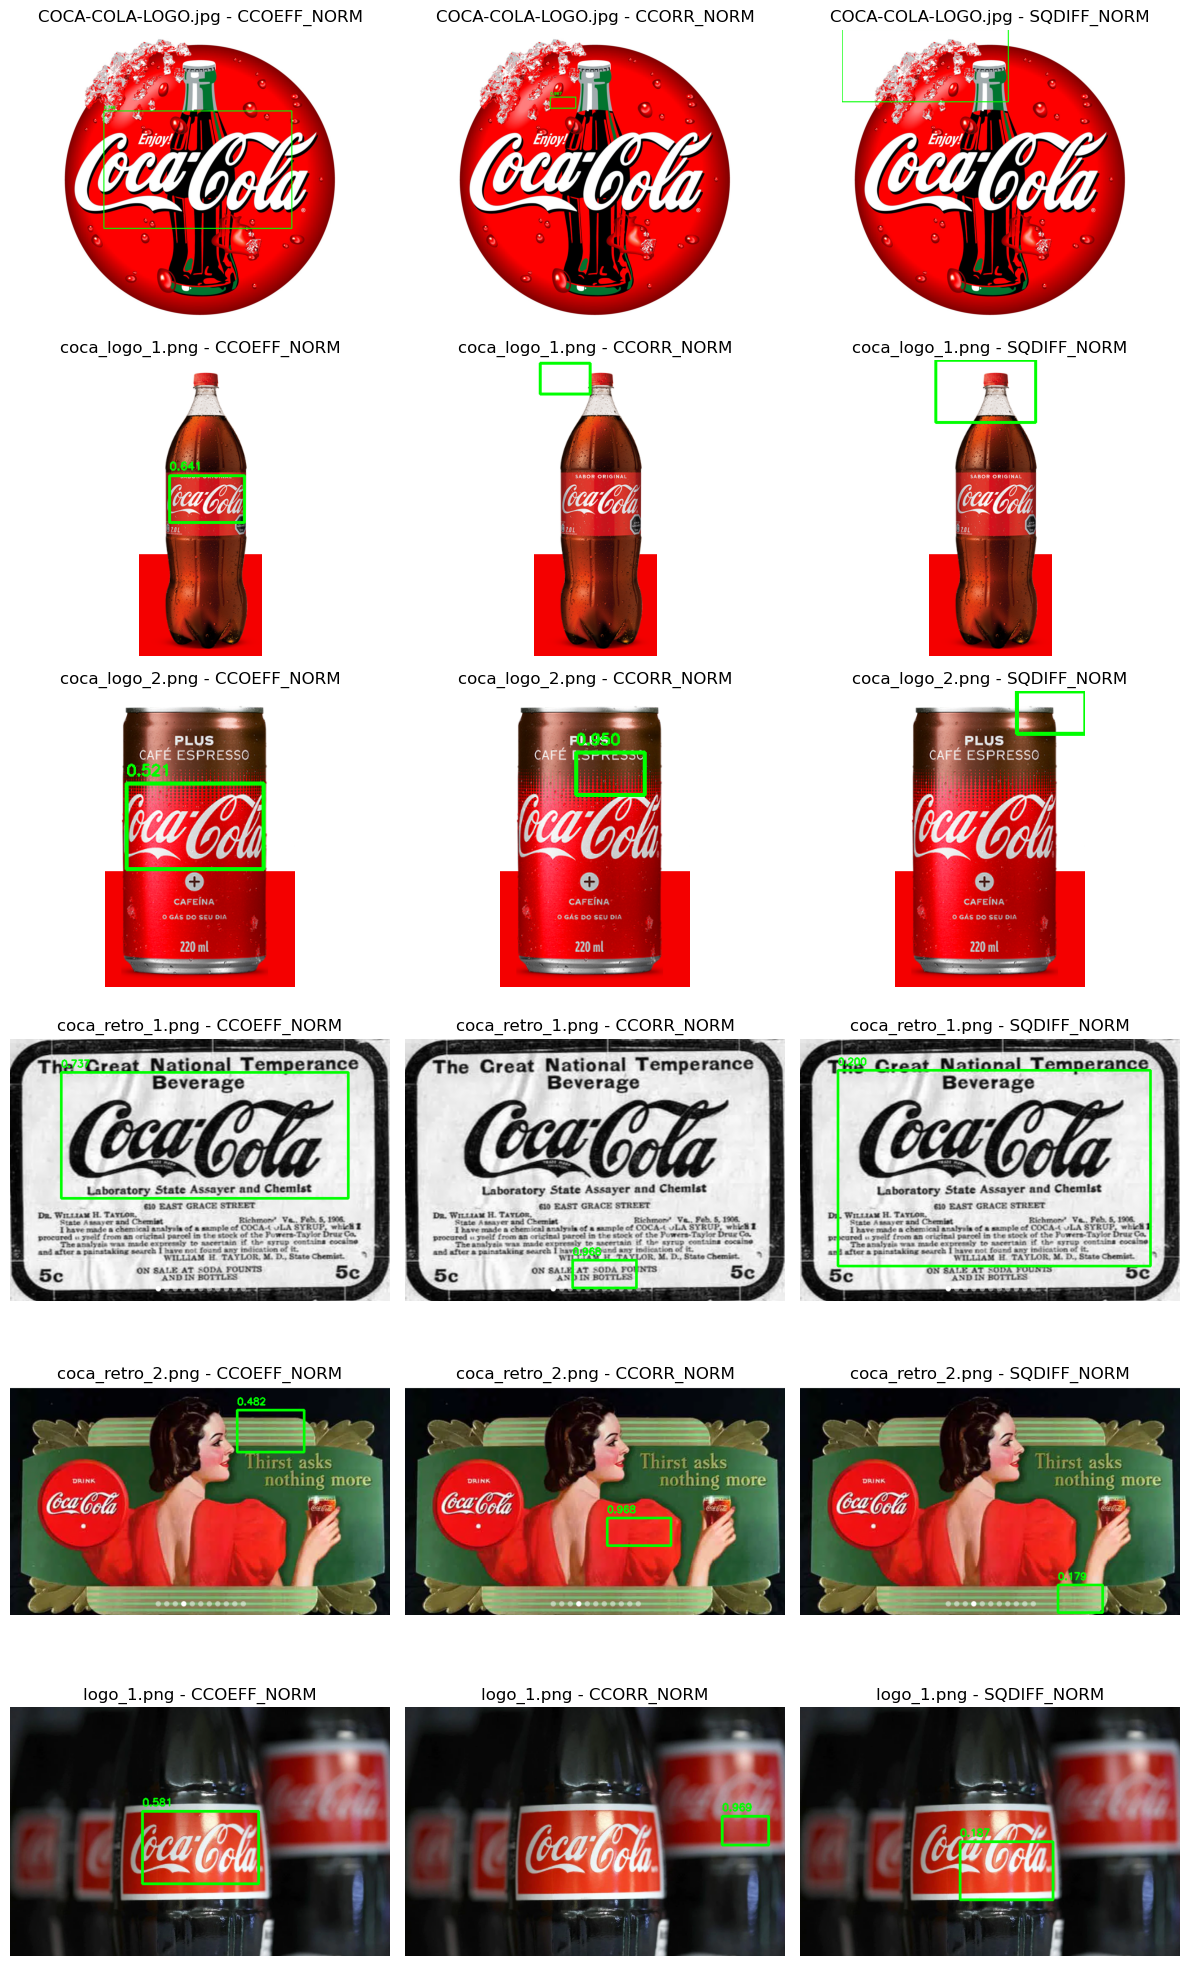

In [114]:
fig, axs = plt.subplots(len(dataset), len(methods), figsize=(12, 20))

for i, img in enumerate(dataset):

    for j, (name, method, thr) in enumerate(methods):

        boxes, scores = detect_object(img.copy(), scaled_templates, method, thr)

        canvas = img.copy()

        
        
        if len(scores) > 0:
            best_idx = np.argmax(scores)

            x, y, w, h = boxes[best_idx]
            best_score = scores[best_idx]

            cv2.rectangle(canvas, (x, y), (x + w, y + h), (0,255,0), 3)
            cv2.putText(canvas, f"{best_score:.3f}",
                        (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0,255,0),
                        2)
        else:
            print(f"{names[i]}: sin detección")


        axs[i, j].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
        axs[i, j].set_title(f"{names[i]} - {name}")
        axs[i, j].axis("off")

plt.tight_layout()
plt.show()

Se puede observar que los resultados con mas precisión se obtienen para el método TM_CCOEFF_NORMED, donde no hay falsos positivos salvo en la coca_retro_2.png donde habria que re-analizar

## Punto 2 - Detección múltiple en imagen multi_coca


In [102]:
def multiple_template_matching(img, template, threshold=0.5):
    
    proc = preprocess_frame(img)

    h, w = template.shape

    # matching
    res = cv2.matchTemplate(proc, template, cv2.TM_CCOEFF_NORMED)

    # puntos que superan el threshold
    loc = np.where(res > threshold)

    # armar cajas
    boxes = [(x, y, x + w, y + h) for x, y in zip(*loc[::-1])]
    scores = [res[y, x] for x, y in zip(*loc[::-1])]

    boxes_nms, scores_nms = apply_nms(
        [[x1, y1, x2-x1, y2-y1] for (x1, y1, x2, y2) in boxes],
        scores,
        0.3
    )

    # volver a formato original (x1,y1,x2,y2)
    final_boxes = [(x, y, x+w, y+h) for (x, y, w, h) in boxes_nms]

    if len(final_boxes) == 0:
        return [], [], res

    return final_boxes, scores_nms, res

In [103]:
multi_img = cv2.imread(os.path.join(DATASET_DIR, "coca_multi.png"))

if multi_img is None:
    raise Exception("No se pudo cargar la imagen coca_multi.png")

# uso el template que funcionó en punto anterior
selected_template = templates_bank[3][1]  # crop_neg

# ajustar escala
selected_template = cv2.resize(selected_template, None, fx=0.25, fy=0.25)

boxes, scores, heatmap = multiple_template_matching(
    multi_img.copy(),
    selected_template,
    threshold=0.53
)


(np.float64(-0.5), np.float64(69.5), np.float64(43.5), np.float64(-0.5))

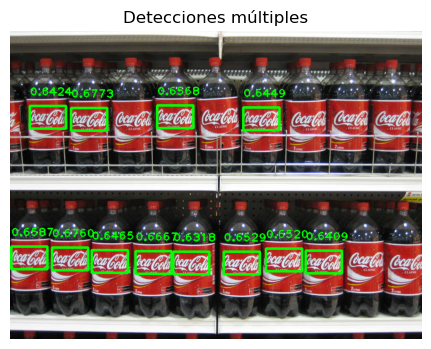

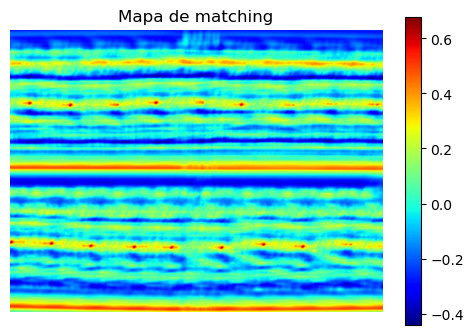

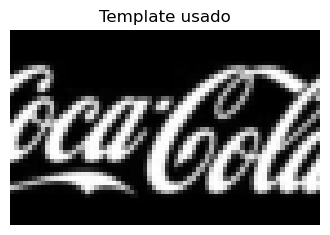

In [104]:
output = multi_img.copy()

for (x1, y1, x2, y2), score in zip(boxes, scores):
    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(output,
                f"{score:.4f}",
                (x1, y1-20),
                cv2.FONT_HERSHEY_PLAIN,
                1.5,
                (0, 255, 0),
                2)

plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detecciones múltiples")
plt.axis("off")

# heatmap
plt.figure(figsize=(6,4))
plt.imshow(heatmap, cmap="jet")
plt.title("Mapa de matching")
plt.colorbar()
plt.axis("off")

# template
plt.figure(figsize=(4,4))
plt.imshow(selected_template, cmap="gray")
plt.title("Template usado")
plt.axis("off")

Se evidencia la necesidad de seguir trabajando en el ajuste del algoritmo y en la etapa de preprocesamiento de las imágenes, aunque puede detectar con buena exactitud multiples logos de manera correcta.

## Punto 3 - Generalización para todas las IMG

In [99]:
# Preprocesar template
base = preprocess_frame(template_color)

templates = [
    base,
    255 - base,
    base[:, 50:340],
    (255 - base)[:, 50:340]
]

# Pirámide
def build_pyramid(template):
    pyramid = []

    for scale in np.arange(0.2, 3.0, 0.1):
        resized = cv2.resize(template, None, fx=scale, fy=scale)

        if resized.shape[0] > 10 and resized.shape[1] > 10:
            pyramid.append(resized)

    return pyramid


template_pyramid = []
for t in templates:
    template_pyramid.extend(build_pyramid(t))

print("Templates en pirámide:", len(template_pyramid))

Templates en pirámide: 112


In [100]:
def detect_multi_scale(img, templates, thr=0.45, iou_thr=0.1):
    proc = preprocess_frame(img)

    boxes = []
    scores = []

    for t in templates:
        h, w = t.shape

        if h > proc.shape[0] or w > proc.shape[1]:
            continue

        res = cv2.matchTemplate(proc, t, cv2.TM_CCOEFF_NORMED)
        ys, xs = np.where(res > thr)

        for (x, y) in zip(xs, ys):
            boxes.append([x, y, w, h])
            scores.append(res[y, x])

    if len(boxes) == 0:
        return [], []

    boxes_nms, scores_nms = apply_nms(boxes, scores, iou_thr)

    final_boxes = [(x, y, x + w, y + h) for (x, y, w, h) in boxes_nms]

    return final_boxes, scores_nms

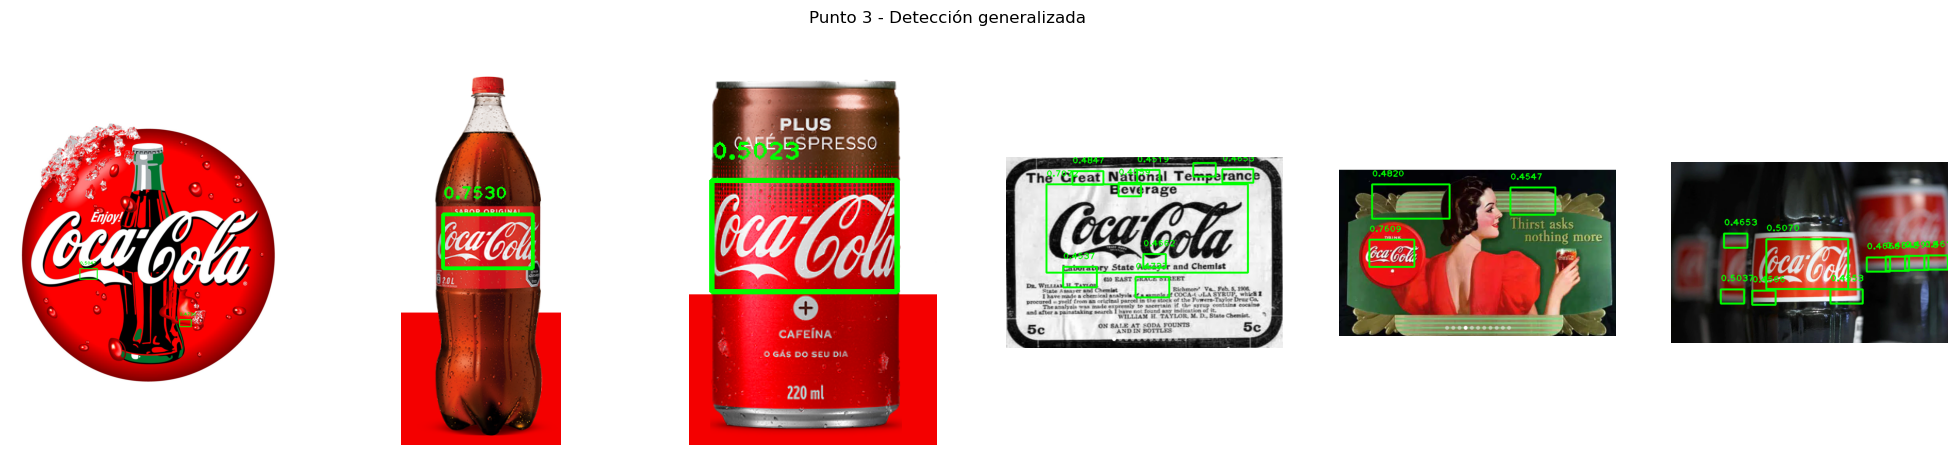

In [ ]:
fig, axs = plt.subplots(1, len(dataset), figsize=(25,5))

# por si hay un solo elemento
if len(dataset) == 1:
    axs = [axs]

for ax, img in zip(axs, dataset):

    boxes, scores = detect_multi_scale(
        img.copy(),
        template_pyramid,
        thr=0.45,      
        iou_thr=0.1    
    )

    output = img.copy()

    for (x1, y1, x2, y2), s in zip(boxes, scores):
        cv2.rectangle(output, (x1, y1), (x2, y2), (0,255,0), 3)
        cv2.putText(output,
                    f"{s:.4f}",
                    (x1, y1-20),
                    cv2.FONT_HERSHEY_PLAIN,
                    1.5,
                    (0,255,0),
                    2)

    ax.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    ax.axis("off")

plt.suptitle("Punto 3 - Detección generalizada")
plt.show()

Se puede observar que hay 1 entrada en las que algoritmo no pudo detectar el logo. Sería ideal continuar trabajando en refinar el algoritmo y el preprocesamiento de las entradas.